# ScenarioMIP — CO₂ flux extensions

This notebook reproduces the comprehensive CO₂ flux figure from the ScenarioMIP
description paper for seven scenarios (VL through HL), spanning 1750–2500.

For each scenario it plots two panels:

* **Annual fluxes** — gross positive CO₂ from energy & industry, AFOLU,
  and a breakdown of negative CDR components (BECCS, DACCS, ocean CDR,
  enhanced weathering).
* **Cumulative fluxes** — the same components integrated over time, with
  reference lines for proven/probable fossil reserves and the cumulative
  CDR limit.

Inputs are two CSVs in `data/`:

* `continuous_emissions_timeseries_1750_2500.csv` — full 1750–2500 series at
  the World region (gross positive, AFOLU, energy & industry).
* `cdr_components_future.csv` — future-only (2023–2500) CDR sub-components,
  pre-summed across regions.


## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Load data

In [2]:
DATA_DIR = Path.cwd().parent / "data"

raw_output = pd.read_csv(DATA_DIR / "continuous_emissions_timeseries_1750_2500.csv")
raw_output = raw_output.set_index(["model", "scenario", "region", "workflow", "variable", "unit"])
raw_output.columns = raw_output.columns.astype(float)

cdr_components = pd.read_csv(DATA_DIR / "cdr_components_future.csv")
cdr_components = cdr_components.set_index(["model", "scenario", "variable"])
cdr_components.columns = cdr_components.columns.astype(float)

print(f"raw_output: {raw_output.shape}, years {raw_output.columns.min():.0f}-{raw_output.columns.max():.0f}")
print(f"cdr_components: {cdr_components.shape}, years {cdr_components.columns.min():.0f}-{cdr_components.columns.max():.0f}")


raw_output: (378, 751), years 1750-2500
cdr_components: (28, 478), years 2023-2500


## Constants and scenario metadata

In [3]:
BASELINE_YEAR = 2100
CDR_LIMIT = -1460          # Gt CO2 -- cumulative CDR ceiling
PROVED_FOSSIL_RESERVES = 2032 + 2400    # Gt CO2
PROBABLE_FOSSIL_RESERVES = 8036 + 2400  # Gt CO2

scenario_model_match = {
    "VL": ["SSP1 - Very Low Emissions", "REMIND-MAgPIE 3.5-4.11", "tab:blue"],
    "LN": ["SSP2 - Low Overshoot_a", "AIM 3.0", "tab:cyan"],
    "L":  ["SSP2 - Low Emissions", "MESSAGEix-GLOBIOM-GAINS 2.1-M-R12", "tab:green"],
    "ML": ["SSP2 - Medium-Low Emissions", "COFFEE 1.6", "tab:pink"],
    "M":  ["SSP2 - Medium Emissions", "IMAGE 3.4", "tab:purple"],
    "H":  ["SSP3 - High Emissions", "GCAM 8s", "tab:red"],
    "HL": ["SSP5 - Medium-Low Emissions_a", "WITCH 6.0", "tab:brown"],
}
scenario_to_code = {info[0]: code for code, info in scenario_model_match.items()}

COLORS = {
    "Gross_Positive":      "#8B4513",
    "BECCS":               "#BEDB3C",
    "DACCS":               "#DF23D9",
    "Ocean":               "#4D3EBD",
    "Enhanced_Weathering": "#A6A6A6",
    "AFOLU":               "#51E390",
}


## Plot helpers

In [4]:
def _series_by_scenario_variable(df, scenario, variable, years):
    """Sum rows matching (scenario, variable) and return a 1D ndarray over `years`."""
    mask = (
        (df.index.get_level_values("scenario") == scenario)
        & (df.index.get_level_values("variable") == variable)
    )
    sub = df.loc[mask, years]
    if sub.empty:
        return np.zeros(len(years))
    return sub.sum(axis=0).values


def _cdr_future_padded(scenario, variable, all_years, future_years):
    """CDR sub-component: zero over the historical period, future values after."""
    mask = (
        (cdr_components.index.get_level_values("scenario") == scenario)
        & (cdr_components.index.get_level_values("variable") == variable)
    )
    vals = cdr_components.loc[mask, future_years].sum(axis=0).values
    return np.concatenate([np.zeros(len(all_years) - len(future_years)), vals])


def _get_scenario_data(scenario, all_years, future_years):
    """Assemble all series needed to plot one scenario, in Gt CO2 / yr."""
    return {
        "gross_pos": _series_by_scenario_variable(raw_output, scenario, "Emissions|CO2|Gross Positive Emissions", all_years) / 1000,
        "fossil":    _series_by_scenario_variable(raw_output, scenario, "Emissions|CO2|Energy and Industrial Processes", all_years) / 1000,
        "afolu":     _series_by_scenario_variable(raw_output, scenario, "Emissions|CO2|AFOLU", all_years) / 1000,
        "beccs":     _cdr_future_padded(scenario, "Emissions|CO2|BECCS",               all_years, future_years) / 1000,
        "daccs":     _cdr_future_padded(scenario, "Emissions|CO2|Direct Air Capture",  all_years, future_years) / 1000,
        "ocean":     _cdr_future_padded(scenario, "Emissions|CO2|Ocean",               all_years, future_years) / 1000,
        "ew":        _cdr_future_padded(scenario, "Emissions|CO2|Enhanced Weathering", all_years, future_years) / 1000,
    }


def _plot_annual(ax, data, years):
    afolu_pos = np.clip(data["afolu"], 0, None)
    afolu_neg = np.clip(data["afolu"], None, 0)

    y1_pos = data["gross_pos"]
    y2_pos = y1_pos + afolu_pos
    y1_neg = data["beccs"]
    y2_neg = y1_neg + data["daccs"]
    y3_neg = y2_neg + data["ocean"]
    y4_neg = y3_neg + data["ew"]
    y5_neg = y4_neg + afolu_neg

    ax.fill_between(years, 0,       y1_pos, alpha=0.7, color=COLORS["Gross_Positive"],      label="Gross FF&I")
    ax.fill_between(years, y1_pos,  y2_pos, alpha=0.7, color=COLORS["AFOLU"],               label="AFOLU")
    ax.fill_between(years, 0,       y1_neg, alpha=0.7, color=COLORS["BECCS"],               label="BECCS")
    ax.fill_between(years, y1_neg,  y2_neg, alpha=0.7, color=COLORS["DACCS"],               label="DACCS")
    ax.fill_between(years, y2_neg,  y3_neg, alpha=0.7, color=COLORS["Ocean"],               label="Ocean CDR")
    ax.fill_between(years, y3_neg,  y4_neg, alpha=0.7, color=COLORS["Enhanced_Weathering"], label="Enhanced Weathering")
    ax.fill_between(years, y4_neg,  y5_neg, alpha=0.7, color=COLORS["AFOLU"])

    ax.plot(years, data["fossil"] + data["afolu"], "k-", linewidth=2, alpha=0.8, label="Net Emissions")


def _plot_cumulative(ax, data, years):
    afolu_pos = np.clip(data["afolu"], 0, None)
    afolu_neg = np.clip(data["afolu"], None, 0)

    gp_cum    = np.cumsum(data["gross_pos"])
    afolu_cum = np.cumsum(afolu_pos + afolu_neg)
    beccs_cum = np.cumsum(data["beccs"])
    daccs_cum = np.cumsum(data["daccs"])
    ocean_cum = np.cumsum(data["ocean"])
    ew_cum    = np.cumsum(data["ew"])

    y1_pos = gp_cum
    y2_pos = y1_pos + afolu_cum
    y1_neg = beccs_cum
    y2_neg = y1_neg + daccs_cum
    y3_neg = y2_neg + ocean_cum
    y4_neg = y3_neg + ew_cum

    ax.fill_between(years, 0,      y1_pos, alpha=0.7, color=COLORS["Gross_Positive"])
    ax.fill_between(years, y1_pos, y2_pos, alpha=0.7, color=COLORS["AFOLU"])
    ax.fill_between(years, 0,      y1_neg, alpha=0.7, color=COLORS["BECCS"])
    ax.fill_between(years, y1_neg, y2_neg, alpha=0.7, color=COLORS["DACCS"])
    ax.fill_between(years, y2_neg, y3_neg, alpha=0.7, color=COLORS["Ocean"])
    ax.fill_between(years, y3_neg, y4_neg, alpha=0.7, color=COLORS["Enhanced_Weathering"])

    fossil_cum = np.cumsum(data["fossil"])
    ax.plot(years, fossil_cum + afolu_cum, "k-", linewidth=2, alpha=0.8, label="Net Emissions")


def _format_axes(ax_annual, ax_cumul, scenario, row_index, all_years):
    for ax, suffix in [(ax_annual, "Annual Gross Fluxes"), (ax_cumul, "Cumulative Gross Fluxes")]:
        ax.set_title(f"{scenario_to_code[scenario]} {suffix}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Year", fontsize=11)
        ax.set_ylabel(
            "CO₂ Flux (Gt CO₂/yr)" if ax is ax_annual else "Cumulative CO₂ (Gt CO₂)",
            fontsize=11,
        )
        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(all_years[0], all_years[-1])
        ax.axvline(x=BASELINE_YEAR, color="red", linestyle="--", alpha=0.5, linewidth=1)
        ax.axhline(y=0, color="black", linestyle="-", alpha=0.3, linewidth=2)

        if ax is ax_cumul:
            ax.axhline(y=CDR_LIMIT,                color="green", linestyle="-",  alpha=0.3, linewidth=3, label="Cumulative CDR limit")
            ax.axhline(y=PROVED_FOSSIL_RESERVES,   color="red",   linestyle="-",  alpha=0.3, linewidth=3, label="Proved Fossil Reserves")
            ax.axhline(y=PROBABLE_FOSSIL_RESERVES, color="red",   linestyle="--", alpha=0.3, linewidth=3, label="Proved + Probable Fossil Reserves")
        if row_index == 0:
            ax.legend(loc="upper right", fontsize=9)


def plot_comprehensive_co2_analysis_with_history():
    all_years = sorted(c for c in raw_output.columns if isinstance(c, (int, float)))
    future_years = sorted(c for c in cdr_components.columns if isinstance(c, (int, float)))

    scenarios = sorted(
        set(raw_output.index.get_level_values("scenario"))
        & set(cdr_components.index.get_level_values("scenario"))
    )
    n = len(scenarios)
    print(f"Plotting {n} scenarios across {len(all_years)} years")

    fig, axes = plt.subplots(n, 2, figsize=(10, 3 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    years_arr = np.array(all_years)
    for i, scenario in enumerate(scenarios):
        data = _get_scenario_data(scenario, all_years, future_years)
        _plot_annual(axes[i, 0], data, years_arr)
        _plot_cumulative(axes[i, 1], data, years_arr)
        _format_axes(axes[i, 0], axes[i, 1], scenario, i, all_years)

    plt.tight_layout()
    return fig


## Render

Plotting 7 scenarios across 751 years
Saved /Users/bensan/ScenarioMIP_final/plots/co2_extensions_with_history.png


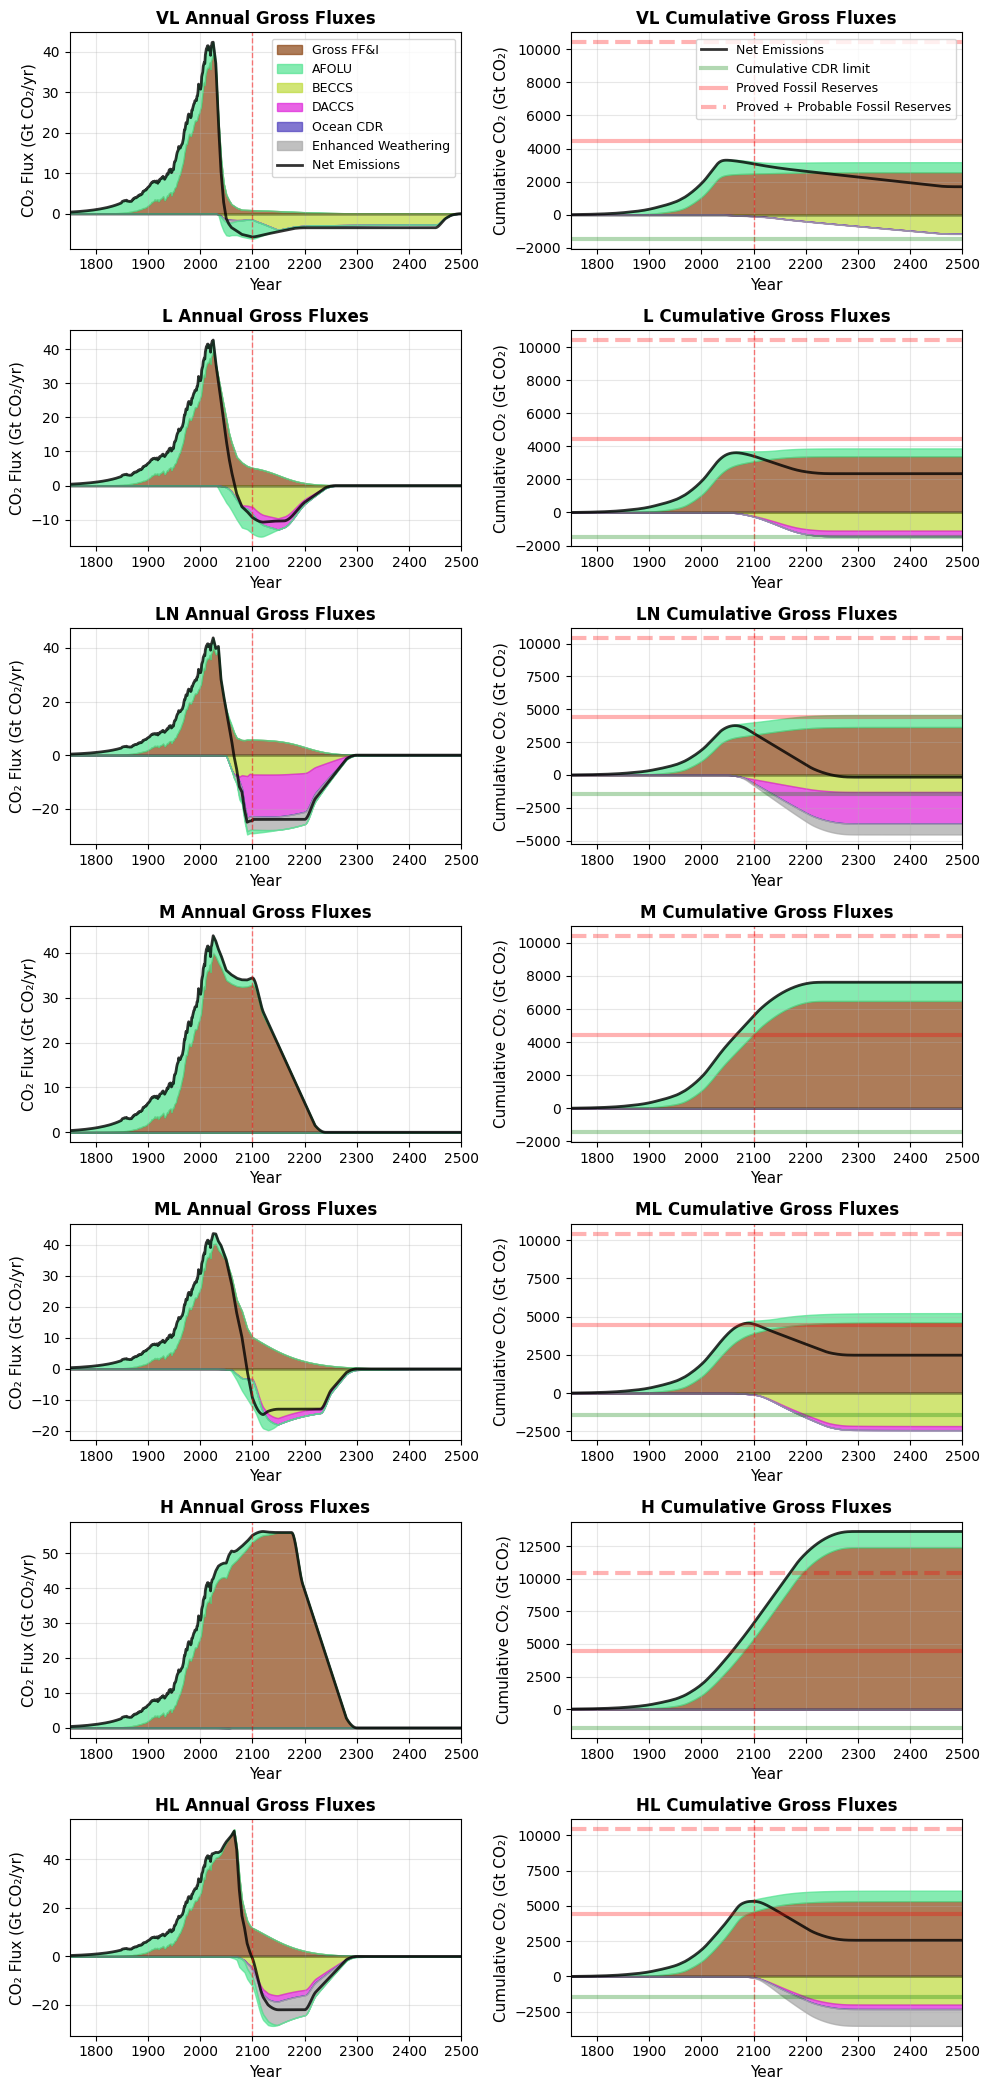

In [5]:
fig = plot_comprehensive_co2_analysis_with_history()
out_path = Path.cwd().parent / "plots" / "co2_extensions_with_history.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()
